<a href="https://colab.research.google.com/github/DArturo-LR/Visualizador-de-datos-m-dicos/blob/main/Visualizador_de_datos_m%C3%A9dicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Importar los datos del archivo CSV (Al leerlo, Pandas lo transforma en el DataFrame 'df')
df = pd.read_csv('medical_examination.csv')

# 2. Agregar la columna 'overweight' (Sobrepeso)
# El IMC se calcula: peso (kg) / [altura (m)]^2. Como la altura viene en cm, la dividimos entre 100.
# Si el IMC es > 25, asigna 1 (sobrepeso), de lo contrario 0.
imc = df['weight'] / ((df['height'] / 100) ** 2)
df['overweight'] = (imc > 25).astype(int)

# 3. Normalizar los datos de 'cholesterol' y 'gluc' (0 = bueno, 1 = malo)
# Si el valor original es 1 (normal), se convierte en 0. Si es mayor que 1, se convierte en 1.
df['cholesterol'] = (df['cholesterol'] > 1).astype(int)
df['gluc'] = (df['gluc'] > 1).astype(int)


# 4. Función para dibujar el Gráfico Categórico (Cat Plot)
def draw_cat_plot():
    # 5. Reestructurar el DataFrame usando pd.melt para el gráfico de barras por categorías
    # Usamos 'cardio' como la columna pivote (id) para separar a los pacientes sanos de los enfermos
    df_cat = pd.melt(df, id_vars=['cardio'], value_vars=['cholesterol', 'gluc', 'smoke', 'alco', 'active', 'overweight'])

    # 6. Agrupar los datos para contar cuántos "buenos" (0) y "malos" (1) hay de cada variable por cada grupo de 'cardio'
    df_cat = df_cat.groupby(['cardio', 'variable', 'value']).size().reset_index(name='total')

    # 7. Crear el gráfico utilizando la función catplot de Seaborn
    # 'col=cardio' creará dos paneles: uno para cardio=0 y otro para cardio=1
    grafico = sns.catplot(
        x='variable',
        y='total',
        hue='value',
        col='cardio',
        data=df_cat,
        kind='bar'
    )

    # 8. Guardar la figura generada en la variable 'fig'
    fig = grafico.fig

    # 9. No modificar estas líneas (necesarias para las pruebas de freeCodeCamp)
    fig.savefig('catplot.png')
    return fig


# 10. Función para dibujar el Mapa de Calor (Heat Map)
def draw_heat_map():
    # 11. Limpiar los datos eliminando registros incorrectos mediante filtros percentiles
    df_heat = df[
        (df['ap_lo'] <= df['ap_hi']) & # Presión diastólica debe ser menor o igual a la sistólica
        (df['height'] >= df['height'].quantile(0.025)) & # Altura mayor o igual al percentil 2.5%
        (df['height'] <= df['height'].quantile(0.975)) & # Altura menor o igual al percentil 97.5%
        (df['weight'] >= df['weight'].quantile(0.025)) & # Peso mayor o igual al percentil 2.5%
        (df['weight'] <= df['weight'].quantile(0.975))   # Peso menor o igual al percentil 97.5%
    ]

    # 12. Calcular la matriz de correlación entre todas las variables
    corr = df_heat.corr()

    # 13. Generar una máscara booleana para ocultar el triángulo superior de la matriz (evita duplicados)
    mask = np.triu(np.ones_like(corr, dtype=bool))

    # 14. Configurar el lienzo de la figura de matplotlib
    fig, ax = plt.subplots(figsize=(12, 12))

    # 15. Graficar la matriz de correlación usando el mapa de calor de Seaborn
    sns.heatmap(
        corr,
        mask=mask,
        annot=True, # Muestra los números de correlación dentro de cada cuadro
        fmt=".1f", # Redondea los números a 1 decimal
        cmap='coolwarm', # Escala de colores de frío (azul) a calor (rojo)
        vmax=0.3,
        vmin=-0.1,
        center=0,
        square=True, # Cuadros perfectamente cuadrados
        linewidths=.5,
        cbar_kws={"shrink": .5} # Reduce el tamaño de la barra de escala de colores
    )

    # 16. No modificar estas líneas
    fig.savefig('heatmap.png')
    return fig

--- GENERANDO GRÁFICO CATEGÓRICO ---


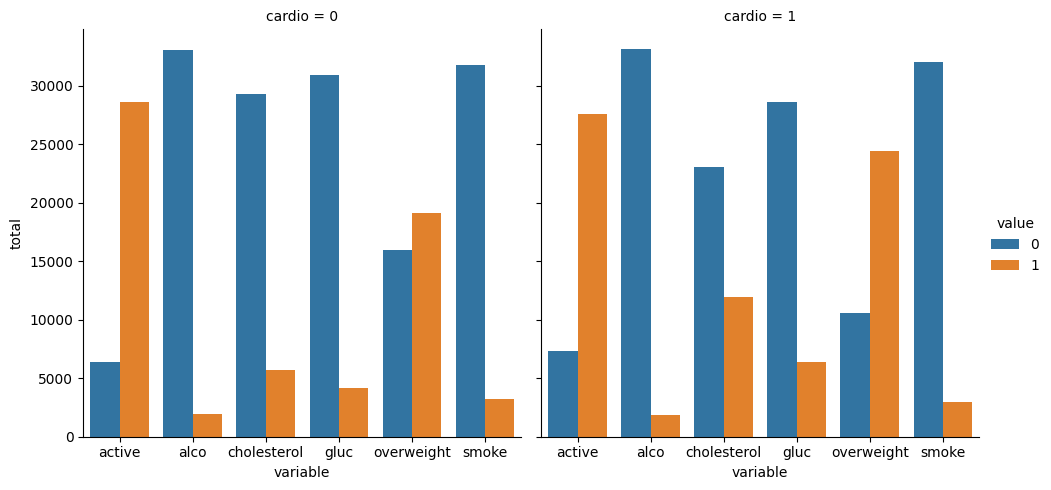


--- GENERANDO MAPA DE CALOR ---


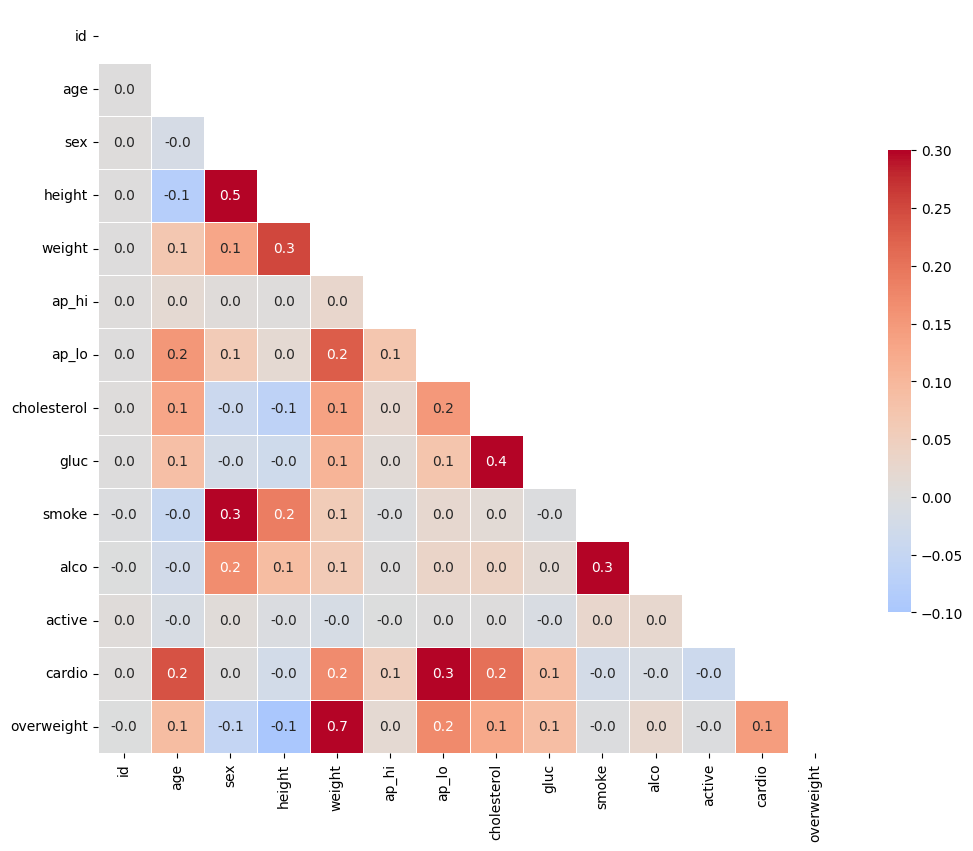

In [2]:
# EJECUTA ESTA CELDA PARA GENERAR LAS VISUALIZACIONES
print("--- GENERANDO GRÁFICO CATEGÓRICO ---")
fig1 = draw_cat_plot()
plt.show()

print("\n--- GENERANDO MAPA DE CALOR ---")
fig2 = draw_heat_map()
plt.show()